# A Sanity Check for Feature Attribution on a Masked Diffusion Language Model

**Bormey Chanchem** · Trier University · term paper companion notebook

This notebook documents how every result in the paper was produced. It has two parts:

| Part | What it does | Where it runs | Executed in this copy? |
|---|---|---|---|
| **A. Attribution runs** | Runs Saliency, Integrated Gradients, Occlusion and the random control on the 5 MDLM-169M checkpoints (base; left/right × 1k/5k) over the 62 PCT statements. Writes one CSV per run to `results/`. | Colab, A100 GPU | No: the 15 output CSVs are committed in `results/` |
| **B. Analysis** | Reads those CSVs and reproduces **Tables 2–4** and **Figures 2–3** of the paper. | Any CPU, a few seconds | **Yes**: outputs below |

To check the paper's numbers, go straight to **Part B**.

---
## Part A: Attribution runs (GPU)

### A.1 Setup
MDLM requires an Ampere-or-newer GPU (A100/L4) because it depends on FlashAttention. There is no official `flash-attn` wheel for torch 2.11, so a community wheel matched to Python 3.13 / CUDA 12.8 is installed. The repository is public, so no token is needed.

In [ ]:
!git clone https://github.com/Bormey-Sky/Advtopic_sanity_check_ar_diffusion.git
%cd Advtopic_sanity_check_ar_diffusion
!pip install -q -r requirements.txt
!pip install -q "https://github.com/lesj0610/flash-attention/releases/download/v2.8.3-cu12-torch2.11/flash_attn-2.8.3%2Bcu12torch2.11cxx11abiTRUE-cp313-cp313-linux_x86_64.whl"

### A.2 Checkpoints
The four LoRA adapters were trained and verified (held-out NormPLL contrast) in prior work: <https://github.com/Bormey-Sky/TNLP_poster_bias_diff_ar>. They are reused unchanged here. The base model is downloaded from the Hugging Face Hub (`kuleshov-group/mdlm-owt`).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ADAPTERS = '/content/drive/MyDrive/0-Trier-Uni/2-summer-semester-2026/NLP/poster_project'
CHECKPOINTS = {                       # (direction, dose): LoRA adapter directory
    ('base',  'base'): None,
    ('left',  '1k'):   f'{ADAPTERS}/checkpoints/mdlm_169m_left',        # rank 16, 3 epochs
    ('left',  '5k'):   f'{ADAPTERS}/checkpoints_v2/mdlm_169m_v2_left',  # rank 32, 5 epochs
    ('right', '1k'):   f'{ADAPTERS}/checkpoints/mdlm_169m_right',
    ('right', '5k'):   f'{ADAPTERS}/checkpoints_v2/mdlm_169m_v2_right',
}

### A.3 Run every method on every checkpoint
One call to `main.py` = one checkpoint × one method → `results/mdlm_169m_{direction}_{dose}_{method}.csv` (long format: one row per statement token).

- Saliency, IG and Occlusion are deterministic.
- The random control is seeded per checkpoint (`RANDOM_SEED + offset` in `main.py`), so its draws are independent across checkpoints but reproducible. Its scores come only from `torch.rand` and do not depend on the model's weights.

In [ ]:
import subprocess

for method in ['saliency', 'integrated_gradients', 'occlusion', 'random_baseline']:
    for (direction, dose), ckpt in CHECKPOINTS.items():
        cmd = ['python', 'main.py', '--method', method, '--direction', direction, '--dose', dose]
        if ckpt is not None:
            cmd += ['--ckpt', ckpt]
        print('>>', ' '.join(cmd[2:]))
        subprocess.run(cmd, check=True)

---
## Part B: Analysis (CPU): reproduces Tables 2–4 and Figures 2–3

Everything below reads only the CSVs in `results/`. The two diagnostic tests are implemented in `utils/diagnostic.py`:

- **Injection-Response (direction):** a statement passes if $\mathrm{sim}(\mathrm{left},\mathrm{right}) < \min\big(\mathrm{sim}(\mathrm{base},\mathrm{left}),\ \mathrm{sim}(\mathrm{base},\mathrm{right})\big)$ at a fixed dose.
- **Dose-Response (strength):** a statement passes if $\mathrm{sim}(\mathrm{base},5\mathrm{k}) < \mathrm{sim}(\mathrm{base},1\mathrm{k})$ for a fixed direction.

$\mathrm{sim}$ is Spearman correlation or top-$k$ overlap ($k = \mathrm{round}(0.3n)$), both computed over content tokens only (punctuation excluded). Each table cell is the **fraction of the 62 statements** for which the ordering held.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

from utils.diagnostic import run_all, summarize_all
from utils.store import run_filename

MODEL, RESULTS_DIR, FIG_DIR = 'mdlm_169m', 'results', 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option('display.precision', 3)

### B.1 What a result file looks like
One row per (statement, token). Here are the first tokens of PCT statement 1 on the base checkpoint (Saliency):

In [2]:
df = pd.read_csv(run_filename(MODEL, 'base', 'base', 'saliency', RESULTS_DIR))
print(f"{df.statement_id.nunique()} statements, {len(df)} token rows")
df[df.statement_id == 1][['statement_id', 'axis', 'token_idx', 'token', 'score']].head(8)

62 statements, 905 token rows


,statement_id,axis,token_idx,token,score
0,1,social,0,If,0.218
1,1,social,1,economic,0.052
2,1,social,2,global,0.037
3,1,social,3,isation,0.167
4,1,social,4,is,0.073
5,1,social,5,inevitable,0.062
6,1,social,6,",",0.157
7,1,social,7,it,0.061


### B.2 Run both tests for every method reading
IG and Occlusion get a magnitude reading (`use_abs=True`) and a signed reading (`use_abs=False`). Saliency is unsigned by construction, and the random control has no meaningful sign, so each gets one row.

The random-control CSVs were not kept after the Colab session. Their fractions were saved at the time in `results/diagnostic_summary.json`, which the code below falls back to. Re-running the five `random_baseline` commands from Part A restores the CSVs, and the code then uses them directly.

In [3]:
READINGS = [  # (row label, method, use_abs)
    ('Random (control)',      'random_baseline',      True),
    ('Saliency',              'saliency',             True),
    ('IG (magnitude)',        'integrated_gradients', True),
    ('IG (signed)',           'integrated_gradients', False),
    ('Occlusion (magnitude)', 'occlusion',            True),
    ('Occlusion (signed)',    'occlusion',            False),
]
METRICS = ['spearman', 'top_k_overlap']
CKPTS = [('base', 'base'), ('left', '1k'), ('left', '5k'), ('right', '1k'), ('right', '5k')]

def have_csvs(method):
    return all(os.path.exists(run_filename(MODEL, d, s, method, RESULTS_DIR)) for d, s in CKPTS)

saved_summary = json.load(open(os.path.join(RESULTS_DIR, 'diagnostic_summary.json')))

fractions, raw = {}, {}   # raw keeps the per-statement DataFrames for Table 3
for label, method, use_abs in READINGS:
    for metric in METRICS:
        if have_csvs(method):
            res = run_all(MODEL, method, use_abs, metric=metric, results_dir=RESULTS_DIR)
            fractions[(label, metric)] = summarize_all(res)
            raw[(label, metric)] = res
        else:
            key = f'{method}__use_abs={use_abs}__{metric}'
            fractions[(label, metric)] = saved_summary[key]
            print(f'[{label} / {metric}] CSVs not found -> using saved fractions from diagnostic_summary.json')

[Random (control) / spearman] CSVs not found -> using saved fractions from diagnostic_summary.json
[Random (control) / top_k_overlap] CSVs not found -> using saved fractions from diagnostic_summary.json


### B.3 Table 2: Injection-Response (does attribution detect *direction*?)
Fraction of statements for which the left- and right-injected attributions were more different from each other than either was from base.

In [4]:
def build_table(test, cols):
    rows = []
    for label, *_ in READINGS:
        row = {}
        for metric, mname in (('spearman', 'Spearman'), ('top_k_overlap', 'Top-k overlap')):
            for c in cols:
                row[(mname, c)] = fractions[(label, metric)][f'{test}_{c}']
        rows.append(pd.Series(row, name=label))
    t = pd.DataFrame(rows)
    t.columns = pd.MultiIndex.from_tuples(t.columns)
    return t

table2 = build_table('injection_response', ['1k', '5k'])
table2.round(3)

Spearman        Top-k overlap       
                            1k     5k            1k     5k
Random (control)         0.290  0.274         0.194  0.194
Saliency                 0.032  0.226         0.016  0.016
IG (magnitude)           0.048  0.274         0.000  0.097
IG (signed)              0.000  0.226         0.032  0.097
Occlusion (magnitude)    0.177  0.355         0.032  0.129
Occlusion (signed)       0.032  0.306         0.016  0.194

In [5]:
margin2 = (table2 - table2.loc['Random (control)']).drop('Random (control)')
print('Margin over the random control (positive = better than chance):')
margin2.round(3)

Margin over the random control (positive = better than chance):


Spearman        Top-k overlap       
                            1k     5k            1k     5k
Saliency                -0.258 -0.048        -0.177 -0.177
IG (magnitude)          -0.242  0.000        -0.194 -0.097
IG (signed)             -0.290 -0.048        -0.161 -0.097
Occlusion (magnitude)   -0.113  0.081        -0.161 -0.065
Occlusion (signed)      -0.258  0.032        -0.177  0.000

Nearly every method sits at or below the random control. The one clear exception is Occlusion at 5k under Spearman (magnitude +0.081, signed +0.032).

### B.4 Table 3: Mean Spearman similarity between checkpoints (magnitude readings)
These are the raw similarities behind Table 2. B = base, L = left, R = right. Injection-Response counts, per statement, how often L–R is the smallest of the three.

In [6]:
rows = []
for label in ['Saliency', 'IG (magnitude)', 'Occlusion (magnitude)']:
    ir = raw[(label, 'spearman')]['injection_response']
    row = {}
    for dose in ['1k', '5k']:
        m = ir[dose][['base_left', 'base_right', 'left_right']].mean()
        row[(dose, 'B–L')], row[(dose, 'B–R')], row[(dose, 'L–R')] = m.values
    rows.append(pd.Series(row, name=label))
table3 = pd.DataFrame(rows)
table3.columns = pd.MultiIndex.from_tuples(table3.columns)
table3.round(3)

1k                   5k              
                         B–L    B–R    L–R    B–L    B–R    L–R
Saliency               0.835  0.846  0.946  0.773  0.723  0.795
IG (magnitude)         0.428  0.438  0.738  0.368  0.410  0.452
Occlusion (magnitude)  0.372  0.361  0.571  0.283  0.209  0.201

### B.5 Table 4: Dose-Response (does attribution detect *strength*?)
Fraction of statements for which the 5k checkpoint moved the attribution further from base than the 1k checkpoint of the same direction.

In [7]:
table4 = build_table('dose_response', ['left', 'right'])
table4.round(3)

Spearman        Top-k overlap       
                          left  right          left  right
Random (control)         0.500  0.516         0.290  0.323
Saliency                 0.613  0.726         0.355  0.387
IG (magnitude)           0.613  0.548         0.323  0.290
IG (signed)              0.677  0.661         0.323  0.435
Occlusion (magnitude)    0.548  0.661         0.323  0.548
Occlusion (signed)       0.710  0.726         0.500  0.484

In [8]:
margin4 = (table4 - table4.loc['Random (control)']).drop('Random (control)')
print('Margin over the random control (positive = better than chance):')
margin4.round(3)

Margin over the random control (positive = better than chance):


Spearman        Top-k overlap       
                          left  right          left  right
Saliency                 0.113  0.210         0.065  0.065
IG (magnitude)           0.113  0.032         0.032 -0.032
IG (signed)              0.177  0.145         0.032  0.113
Occlusion (magnitude)    0.048  0.145         0.032  0.226
Occlusion (signed)       0.210  0.210         0.210  0.161

Under Spearman, every method and reading exceeds the random control (margins +0.032 to +0.210). Under top-$k$ overlap the signal is weaker and less uniform.

### B.6 Figure 2: Margin of each method over the random control
Each dot is a cell of Table 2 (left panels) or Table 4 (right panels) minus the random-control value in the same column. The dashed line at 0 is the random control. Colour marks the method family. A filled marker is the magnitude reading and a hollow marker is the signed reading.

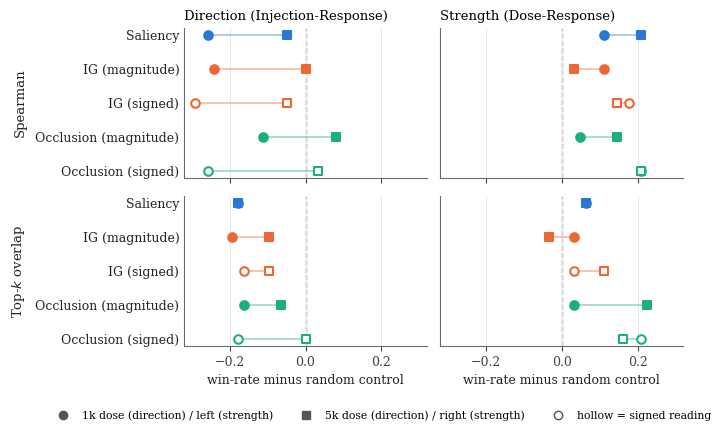

In [9]:
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#6b6b6b', 'axes.labelcolor': '#222222',
    'xtick.color': '#444444', 'ytick.color': '#222222',
})
FAMILY_COLOR = {'Saliency': '#2a78d6', 'IG': '#eb6834', 'Occlusion': '#1baf7a'}
METHODS = [  # (label, family, signed?)
    ('Saliency', 'Saliency', False),
    ('IG (magnitude)', 'IG', False),
    ('IG (signed)', 'IG', True),
    ('Occlusion (magnitude)', 'Occlusion', False),
    ('Occlusion (signed)', 'Occlusion', True),
]

def dot_panel(ax, margins, metric_name, cols, title=None, show_ylabels=True):
    ys = list(range(len(METHODS)))[::-1]
    for y, (m, fam, signed) in zip(ys, METHODS):
        a, b = (margins.loc[m, (metric_name, c)] for c in cols)
        col = FAMILY_COLOR[fam]
        ax.plot([a, b], [y, y], color=col, lw=1.2, alpha=0.45, zorder=1)
        for val, mk in ((a, 'o'), (b, 's')):
            ax.scatter(val, y, marker=mk, s=38, zorder=3,
                       facecolor='white' if signed else col, edgecolor=col, linewidth=1.5)
    ax.axvline(0, color='#8a8a8a', lw=1, ls='--', zorder=0)
    ax.set_yticks(ys)
    ax.set_yticklabels([m for m, *_ in METHODS] if show_ylabels else [])
    ax.tick_params(axis='y', length=0)
    ax.set_xlim(-0.32, 0.32)
    ax.grid(axis='x', color='#e6e6e6', lw=0.6)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontsize=9.5, loc='left')

fig, axes = plt.subplots(2, 2, figsize=(7.0, 4.3), sharex=True)
dot_panel(axes[0, 0], margin2, 'Spearman',      ['1k', '5k'],      'Direction (Injection-Response)')
dot_panel(axes[0, 1], margin4, 'Spearman',      ['left', 'right'], 'Strength (Dose-Response)', show_ylabels=False)
dot_panel(axes[1, 0], margin2, 'Top-k overlap', ['1k', '5k'])
dot_panel(axes[1, 1], margin4, 'Top-k overlap', ['left', 'right'], show_ylabels=False)
axes[0, 0].set_ylabel('Spearman', fontsize=9.5, labelpad=6)
axes[1, 0].set_ylabel('Top-$k$ overlap', fontsize=9.5, labelpad=6)
for ax in axes[1]:
    ax.set_xlabel('win-rate minus random control')

handles = [
    Line2D([], [], ls='', marker='o', mfc='#555', mec='#555', ms=6, label='1k dose (direction) / left (strength)'),
    Line2D([], [], ls='', marker='s', mfc='#555', mec='#555', ms=6, label='5k dose (direction) / right (strength)'),
    Line2D([], [], ls='', marker='o', mfc='white', mec='#555', ms=6, label='hollow = signed reading'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False, fontsize=7.8, bbox_to_anchor=(0.55, -0.01))
fig.tight_layout(rect=(0, 0.06, 1, 1))
fig.savefig(f'{FIG_DIR}/fig2_direction_vs_strength.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig2_direction_vs_strength.png', dpi=200, bbox_inches='tight')
plt.show()

### B.7 Figure 3: Token-level attributions for PCT statement 1 (base checkpoint)
Read directly from the base-checkpoint CSVs. Saliency is unsigned (orange). IG and Occlusion are signed: red raises the stance score $S(x)$ and blue lowers it. Each signed row is scaled symmetrically to its own maximum absolute value. Hatched cells are punctuation, which is excluded from both similarity metrics. Saliency's largest value falls on the final period, which is the attention-sink effect that motivates that exclusion.

Statement 1: "If economic globalisation is inevitable, it should primarily serve humanity rather than the interests of trans-national corporations."


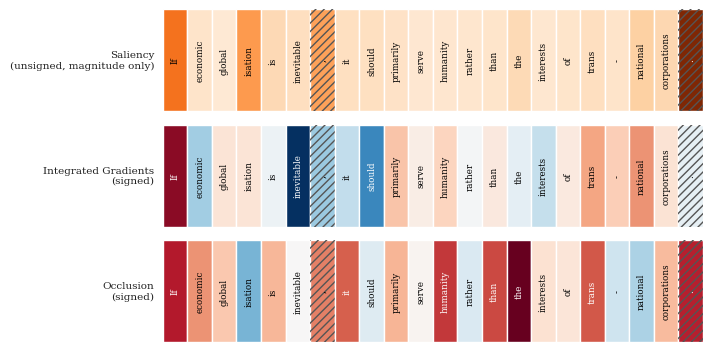

In [10]:
STATEMENT_ID = 1
PUNCT = {'.', ',', '!', '?', ';', ':'}

def statement_scores(method):
    d = pd.read_csv(run_filename(MODEL, 'base', 'base', method, RESULTS_DIR))
    s = d[d.statement_id == STATEMENT_ID].sort_values('token_idx')
    return s.token.tolist(), s.score.to_numpy(), s.text.iloc[0]

rows = [
    ('Saliency\n(unsigned, magnitude only)', 'saliency',             'Oranges', False),
    ('Integrated Gradients\n(signed)',        'integrated_gradients', 'RdBu_r',  True),
    ('Occlusion\n(signed)',                   'occlusion',            'RdBu_r',  True),
]
tokens, _, text = statement_scores('saliency')
print(f'Statement {STATEMENT_ID}: "{text}"')

fig, axes = plt.subplots(len(rows), 1, figsize=(7.2, 3.6))
for ax, (label, method, cmap_name, signed) in zip(axes, rows):
    toks, scores, _ = statement_scores(method)
    assert toks == tokens, 'all methods must share the same tokenization'
    cmap = plt.get_cmap(cmap_name)
    vmax = np.abs(scores).max()
    norm = mcolors.Normalize(vmin=-vmax if signed else 0, vmax=vmax)
    for i, (tok, s) in enumerate(zip(toks, scores)):
        color = cmap(norm(s))
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='white', linewidth=1))
        if tok in PUNCT:
            ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor='none', edgecolor='#555555', hatch='////', linewidth=0))
        r, g, b, _ = color
        textcolor = 'black' if 0.299 * r + 0.587 * g + 0.114 * b > 0.55 else 'white'
        ax.text(i + 0.5, 0.5, tok, ha='center', va='center', fontsize=6.3, color=textcolor, rotation=90)
    ax.set_xlim(0, len(toks)); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, ha='right', va='center', fontsize=7.5, labelpad=6)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig3_token_heatmap_statement1.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Summary

| Test | Result |
|---|---|
| **Direction** (Injection-Response, Table 2) | No method reliably separates left- from right-injected checkpoints. Nearly every cell is at or below the random control; only Occlusion at 5k (Spearman) exceeds it. |
| **Strength** (Dose-Response, Table 4) | Under Spearman, every method exceeds the random control. Mean similarity to base falls from 1k to 5k for every method and direction (Table 3). |
| **Across methods** | Occlusion, the only gradient-free method, is the most consistent. The choice of similarity metric changes the picture more than the choice of attribution method. |

The three methods track **how strongly** MDLM was perturbed considerably better than **in which direction**.